# Clase 7: Análisis no supervisado: construcción de tres bases de datos

## Objetivo
En el análisis no supervisado no existe una variable objetivo (target).
El propósito es explorar la estructura interna de los datos, identificar
patrones, grupos naturales, relaciones latentes o representaciones más
compactas de la información.

Para este análisis se construirán tres versiones del mismo dataset:

1. Base de datos bruta.
2. Base de datos con One-Hot Encoding.
3. Base de datos transformada con PCA.

Esto permite analizar cómo cambia la geometría del espacio de datos
dependiendo del nivel de transformación aplicado.

## 1. Base de datos bruta
Corresponde a los datos originales, luego del proceso de limpieza
(missing values, outliers, etc.), pero sin ninguna transformación
adicional.

Esta base refleja la estructura natural del problema, aunque suele
contener:
- escalas heterogéneas,
- variables categóricas,
- alta dimensionalidad.

## 2. One-Hot Encoding
One-Hot Encoding transforma variables categóricas en variables binarias.
Cada categoría se convierte en una columna.

Esto permite:
- trabajar en un espacio puramente numérico,
- aplicar algoritmos geométricos (distancias, clustering, PCA),
- eliminar la noción de orden artificial en categorías.

El costo es un aumento en la dimensionalidad del espacio.

## 3. PCA (Principal Component Analysis)
PCA es una técnica de reducción de dimensionalidad que proyecta los datos
en un nuevo sistema de ejes ortogonales (componentes principales) que
maximizan la varianza explicada.

Permite:
- eliminar redundancia,
- reducir ruido,
- visualizar datos de alta dimensión,
- facilitar clustering y segmentación.

En términos geométricos, PCA rota el sistema de coordenadas para alinear
los ejes con las direcciones de mayor información.


In [4]:
import pandas as pd
import numpy as np
import ssl #Autorización si es confiable
from sklearn.model_selection import train_test_split
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer

1) Importar una base de datos de forma online

Idea teórica (qué y por qué): 
* En ML normalmente cargamos datos desde una URL (CSV/Parquet) para que el notebook sea reproducible. Con pandas.read_csv(url) puedes traer datos directos desde internet.

In [5]:

ssl._create_default_https_context = ssl._create_unverified_context

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Eliminar target

target = "Survived"

X_unsup = df.drop(columns=[target])

# Tratamiento mínimo de missing (solo para que los algoritmos funcionen)
for col in X_unsup.select_dtypes(include=[np.number]).columns:
    X_unsup[col] = X_unsup[col].fillna(X_unsup[col].mean())

for col in X_unsup.select_dtypes(exclude=[np.number]).columns:
    X_unsup[col] = X_unsup[col].fillna("Missing")


## 1. Base bruta

In [9]:
df_raw = X_unsup.copy()

print(df_raw.shape)
df_raw.head()


(891, 11)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Missing,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Missing,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Missing,S


## 2. Base con One-Hot Encoding

In [11]:
from sklearn.preprocessing import OneHotEncoder

# Identificar categóricas y numéricas
cat_cols_unsup = df_raw.select_dtypes(exclude=[np.number]).columns
num_cols_unsup = df_raw.select_dtypes(include=[np.number]).columns

# One-Hot
ohe = OneHotEncoder(drop="first", sparse_output=False)
X_cat_ohe = ohe.fit_transform(df_raw[cat_cols_unsup])

# Pasar a DataFrame
ohe_feature_names = ohe.get_feature_names_out(cat_cols_unsup)
df_cat_ohe = pd.DataFrame(X_cat_ohe, columns=ohe_feature_names)

# Concatenar con numéricas
df_ohe = pd.concat(
    [df_raw[num_cols_unsup].reset_index(drop=True),
     df_cat_ohe.reset_index(drop=True)],
    axis=1
)

print(df_ohe.shape)
df_ohe.head()


(891, 1727)


,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_Missing,Cabin_T,Embarked_Missing,Embarked_Q,Embarked_S
0,1,3,22.0,1,0,7.2500,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2,1,38.0,1,0,71.2833,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,3,26.0,0,0,7.9250,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,4,1,35.0,1,0,53.1000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,3,35.0,0,0,8.0500,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## 3. PCA

###  Gráfico del codo en PCA (Scree Plot)

## Objetivo
El gráfico del codo en PCA permite visualizar cuánta varianza explica cada
componente principal y determinar cuántos componentes son suficientes para
representar adecuadamente los datos.

Cada componente principal captura una fracción de la varianza total del
dataset. A medida que se agregan componentes, la varianza explicada aumenta,
pero con rendimientos decrecientes.

## Interpretación del "codo"
El punto donde la curva comienza a aplanarse se denomina "codo".
Ese punto indica que agregar más componentes aporta poca información
adicional.


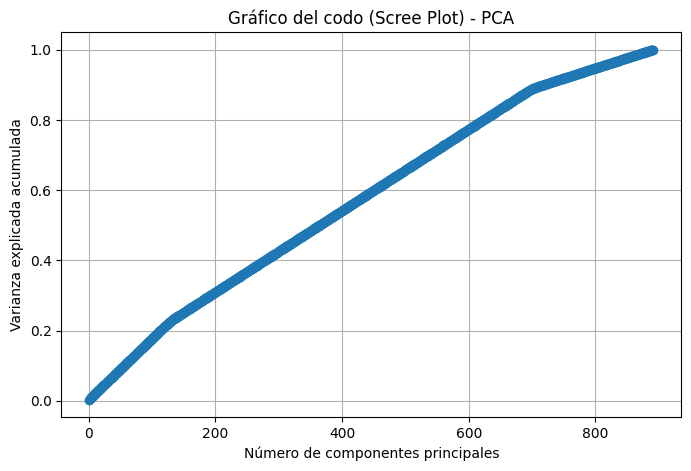

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Escalar datos (obligatorio antes de PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ohe)

# PCA con todas las componentes posibles
pca_full = PCA()
pca_full.fit(X_scaled)

# Varianza explicada
explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

# Gráfico del codo
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_var) + 1), cum_explained_var, marker='o')
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Gráfico del codo (Scree Plot) - PCA")
plt.grid(True)
plt.show()


In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Escalar (obligatorio antes de PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ohe)

# Número real de componentes posibles
max_components = min(700, X_scaled.shape[1])
print("Componentes reales usados:", max_components)

# PCA con hasta 700 componentes
pca_700 = PCA(n_components=max_components)
X_pca_700 = pca_700.fit_transform(X_scaled)

# DataFrame PCA
df_pca_700 = pd.DataFrame(
    X_pca_700,
    columns=[f"PC{i+1}" for i in range(max_components)]
)

print(df_pca_700.shape)
df_pca_700.head()


Componentes reales usados: 700
(891, 700)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC691,PC692,PC693,PC694,PC695,PC696,PC697,PC698,PC699,PC700
0,1.821672,-0.191665,0.071426,0.698911,-1.634155,0.817502,-0.531361,0.349659,0.019937,0.441908,...,0.155366,-2.043316,-0.791332,0.138004,1.737789,0.759666,-2.056507,-0.593887,0.003530,-0.224058
1,-4.294698,0.043235,0.489942,-3.745498,-7.553705,-2.092057,0.671043,1.756176,-1.959370,6.079905,...,0.063207,-0.040964,-0.049493,0.051932,-0.067791,-0.150328,-0.000097,0.022832,0.138971,-0.034486
2,1.364958,-0.089145,0.382729,0.197338,-1.828921,-0.513209,0.391636,1.411877,-0.081695,-0.054642,...,-0.624532,-0.956867,0.916089,0.606712,1.795425,0.604477,0.621748,-0.918631,-0.412628,-0.135195
3,-3.348975,-0.373498,-1.040707,1.426078,-7.058583,-1.125883,-0.327019,0.801861,3.353714,5.065829,...,0.580266,0.198397,-1.616504,-1.541281,1.168493,-0.264483,-2.203357,0.233602,0.325665,1.104159
4,1.560226,0.688577,-0.586927,0.608724,-1.663224,0.968721,-0.114134,0.572413,-0.159171,-0.096301,...,-0.725736,0.331165,-0.450752,0.237302,-0.480935,0.782099,0.585105,-0.261803,-0.174999,-0.040285


# Clase 8. Clustering con K-Means e índice de Silhouette

## Objetivo
Aplicar el algoritmo K-Means sobre la base de datos no supervisada
y evaluar la calidad del clustering mediante el índice de Silhouette.

## K-Means
K-Means es un algoritmo de clustering que busca particionar los datos
en K grupos, minimizando la suma de distancias intra-cluster.

Formalmente, minimiza:
Σ_k Σ_{i en cluster k} ||x_i - μ_k||²

donde μ_k es el centroide del cluster k.

## Índice de Silhouette
El índice de Silhouette mide qué tan bien está asignado cada punto a su cluster.

Para cada observación i:
- a(i): distancia media a puntos de su mismo cluster
- b(i): distancia media al cluster más cercano

Silhouette(i) = (b(i) - a(i)) / max(a(i), b(i))

Valores:
- cercano a 1  → muy buen clustering
- cercano a 0  → clusters superpuestos
- negativo     → mala asignación

Regla práctica:
- < 0.25  → estructura débil
- 0.25–0.5 → estructura razonable
- > 0.5 → estructura fuerte


In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [ ]:
def silhouette_kmeans(X, k_range=range(2, 11)):
    sil_scores = {}
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores[k] = sil
    return pd.DataFrame.from_dict(
        sil_scores, orient="index", columns=["Silhouette"]
    )

Mejor K (OHE): 5 | Silhouette: -0.010461834244964946
Mejor K (PCA): 4 | Silhouette: -0.10582370012102757


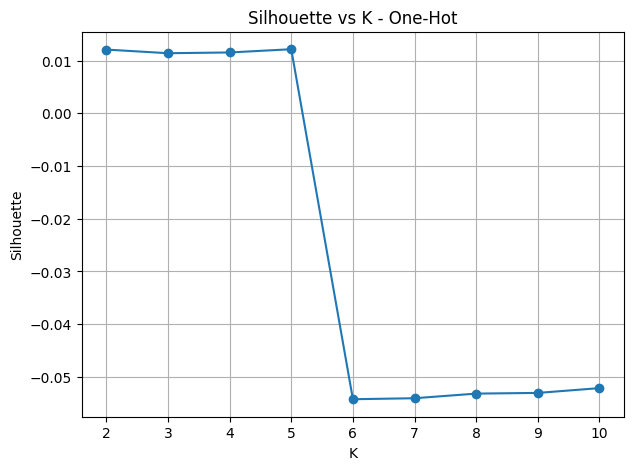

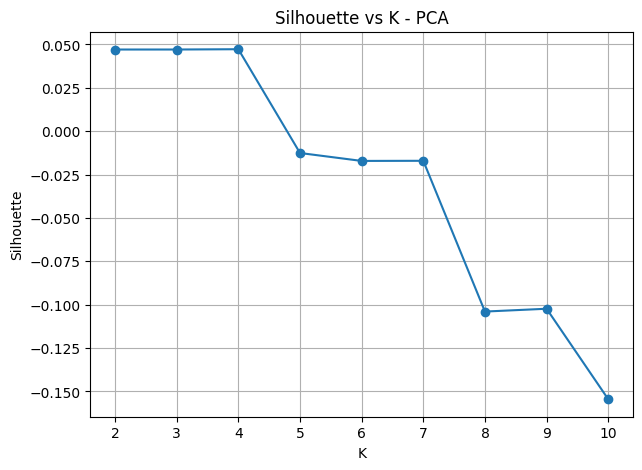

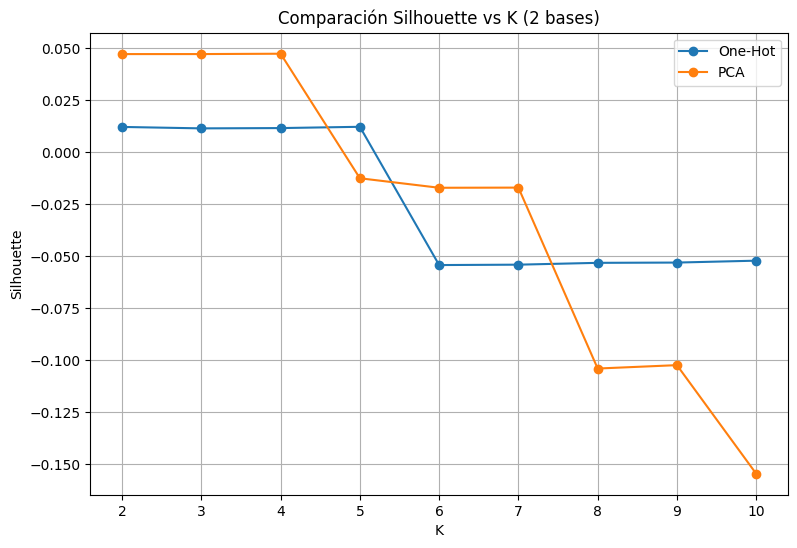

In [40]:
# ------------------------------------------------------------
# 2) Función: entrena KMeans final con el mejor K según Silhouette
# ------------------------------------------------------------
def fit_best_kmeans(X, sil_df, random_state=42):
    best_k = int(sil_df["Silhouette"].idxmax())
    best_km = KMeans(n_clusters=best_k, random_state=random_state, n_init=10)
    best_labels = best_km.fit_predict(X)   # <-- aquí SE CALCULA KMEANS final
    best_sil = silhouette_score(X, best_labels)
    return best_k, best_sil, best_km, best_labels

# ------------------------------------------------------------
# 3) Preparar las 3 bases (asumiendo que YA existen: df_raw, df_ohe, df_pca_700)
#    - Bruta y OneHot se escalan (distancias)
#    - PCA: si ya viene de datos estandarizados, se puede usar directo
# ------------------------------------------------------------
scaler_ohe = StandardScaler()
X_ohe = scaler_ohe.fit_transform(df_ohe)

X_pca = df_pca_700.values  # PCA ya es numérico

# ------------------------------------------------------------
# 4) Silhouette vs K para cada base
# ------------------------------------------------------------
sil_ohe = silhouette_kmeans(X_ohe, range(2, 11))
sil_pca = silhouette_kmeans(X_pca, range(2, 11))

# ------------------------------------------------------------
# 5) Entrenar KMeans FINAL con el mejor K para cada base
# ------------------------------------------------------------
best_k_ohe, best_sil_ohe, km_ohe, labels_ohe = fit_best_kmeans(X_ohe, sil_ohe)
best_k_pca, best_sil_pca, km_pca, labels_pca = fit_best_kmeans(X_pca, sil_pca)

print("Mejor K (OHE):", best_k_ohe, "| Silhouette:", best_sil_ohe)
print("Mejor K (PCA):", best_k_pca, "| Silhouette:", best_sil_pca)

# ------------------------------------------------------------
# 6) Tabla resumen (mejor K por base)
# ------------------------------------------------------------
summary = pd.DataFrame({
    "Base": ["One-Hot", "PCA"],
    "Best_K": [best_k_ohe, best_k_pca],
    "Best_Silhouette": [best_sil_ohe, best_sil_pca]
})
summary
# ------------------------------------------------------------
# 7) Gráficos Silhouette vs K (uno por base) + comparativo
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(sil_ohe.index, sil_ohe["Silhouette"], marker="o")
plt.title("Silhouette vs K - One-Hot")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(sil_pca.index, sil_pca["Silhouette"], marker="o")
plt.title("Silhouette vs K - PCA")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

# Comparativo
# Si tienes sil_raw, puedes agregarlo aquí
# plt.figure(figsize=(9,6))
# plt.plot(sil_raw.index, sil_raw["Silhouette"], marker="o", label="Bruta")
plt.figure(figsize=(9,6))
plt.plot(sil_ohe.index, sil_ohe["Silhouette"], marker="o", label="One-Hot")
plt.plot(sil_pca.index, sil_pca["Silhouette"], marker="o", label="PCA")
plt.title("Comparación Silhouette vs K (2 bases)")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.legend()
plt.grid(True)
plt.show()


In [43]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np


In [44]:
def silhouette_plot(X, labels, title="Silhouette Plot"):
    sil_values = silhouette_samples(X, labels)
    n_clusters = len(np.unique(labels))
    
    y_lower = 10
    plt.figure(figsize=(8, 6))
    
    for i in range(n_clusters):
        ith_cluster_sil = sil_values[labels == i]
        ith_cluster_sil.sort()
        
        size_cluster_i = ith_cluster_sil.shape[0]
        y_upper = y_lower + size_cluster_i
        
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_sil,
            alpha=0.7
        )
        
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    plt.axvline(x=sil_values.mean(), color="red", linestyle="--")
    plt.xlabel("Silhouette coefficient")
    plt.ylabel("Cluster")
    plt.title(title)
    plt.show()


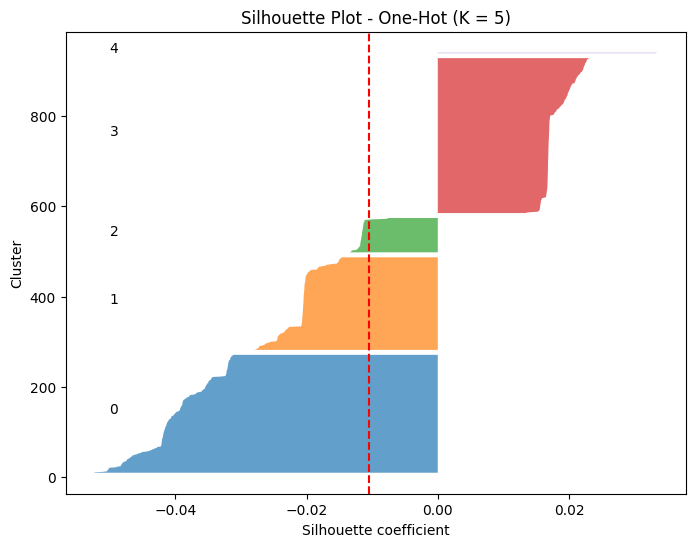

In [45]:
# Asumimos que ya tienes:
# X_ohe (escalado)
# labels_ohe (del mejor kmeans)

silhouette_plot(
    X_ohe,
    labels_ohe,
    title="Silhouette Plot - One-Hot (K = 5)"
)


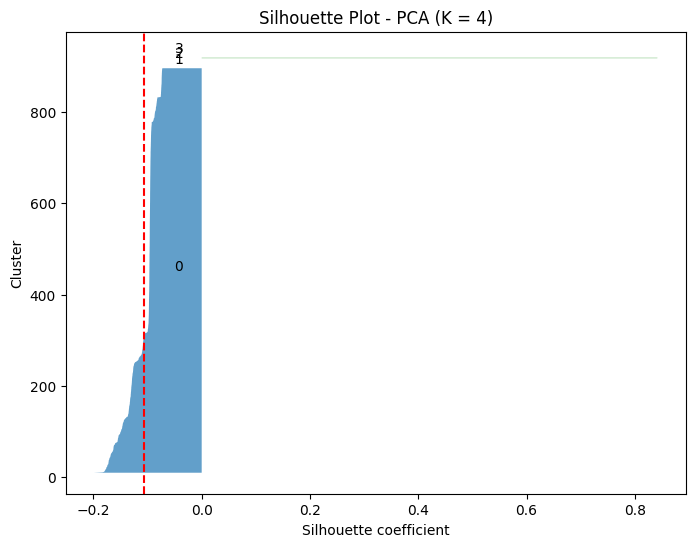

In [46]:
# Asumimos que ya tienes:
# X_pca
# labels_pca

silhouette_plot(
    X_pca,
    labels_pca,
    title="Silhouette Plot - PCA (K = 4)"
)


# Cluster vs. Clase Observada

In [47]:
# Dataset con clusters + target
df_cluster_ohe = df.copy()
df_cluster_ohe["cluster"] = labels_ohe

df_cluster_ohe.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,cluster
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [48]:
cluster_survival = (
    df_cluster_ohe
    .groupby("cluster")["Survived"]
    .agg(
        total="count",
        survival_rate="mean"
    )
    .reset_index()
)

cluster_survival


,cluster,total,survival_rate
0,0,262,0.587786
1,1,206,0.305825
2,2,77,0.389610
3,3,344,0.276163
4,4,2,0.000000


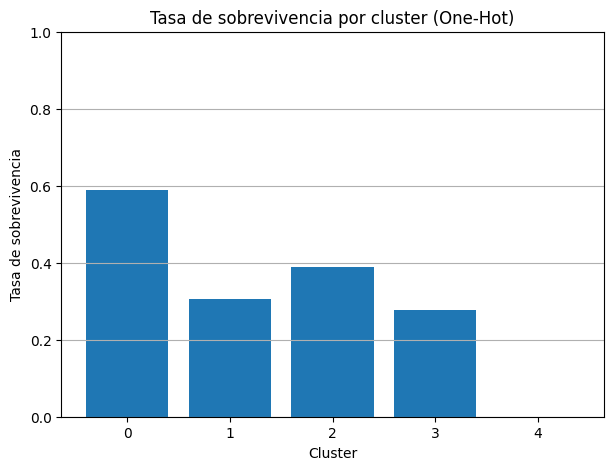

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(
    cluster_survival["cluster"],
    cluster_survival["survival_rate"]
)

plt.xlabel("Cluster")
plt.ylabel("Tasa de sobrevivencia")
plt.title("Tasa de sobrevivencia por cluster (One-Hot)")
plt.ylim(0,1)
plt.grid(axis="y")
plt.show()


In [50]:
pd.crosstab(
    df_cluster_ohe["cluster"],
    df_cluster_ohe["Survived"],
    normalize="index"
)


Survived,0,1
cluster,,
0,0.412214,0.587786
1,0.694175,0.305825
2,0.610390,0.389610
3,0.723837,0.276163
4,1.000000,0.000000
